# Torridon Group ca. 925 Ma paleomagnetic pole

## Geologic context

The Torridon Group is the youngest and thickest of the groups of the "Torridonian" succession of NW Scotland - a Neoproterozoic continental red-bed sequence of dominantly fluvial sandstones (Diabaig, Applecross, and Aultbea formations) deposited unconformably above the older Stoer and Sleat groups and beneath the Cambrian unconformity. These rocks were part of Laurentia.

## Paleomagnetic data

The pole is the Lulea Working Group (2009) sample-weighted grand mean of seven Torridon Group paleomagnetic studies - Irving & Runcorn (1957), Stewart & Irving (1974), Smith et al. (1983), Torsvik & Sturt (1987), Potts (1990), Williams & Schmidt (1997), and Borradaile & Geneviciene (2008) - as carried in the Evans et al. (2021) Laurentia compilation. The tilt-corrected mean direction is Dec 119.6 deg / Inc 56.7 deg, giving a pole at **-17.7 deg N / 220.9 deg E (A95 = 7.1 deg)** from N = 880 samples, with mixed (normal + reverse) polarity.

## Age

The Torridon Group is poorly dated directly. Its youngest detrital zircon populations indicate deposition younger than ca. 1050 Ma (as summarized by Krabbendam et al., 2022), while the absence of Cryogenian glacial deposits indicates it is older than ca. 720 Ma. The pole is assigned **ca. 925 Ma (780-1070 Ma)**; in terms of apparent-polar-wander comparison it is quite similar to the ca. 990 Ma Jacobsville pole.

## Reference frame

These rocks belong to the **Laurentia-Scotland** terrane: restoring the pole into the Laurentia reference frame requires an Euler rotation. The **Nordic summary below is exported in the unrotated, present-day Scottish coordinates** (applying the rotation to the compilation is left to downstream paleogeographic workflows). For assessment, the pole is shown below in **both** its unrotated and its rotated position, using the Scotland-to-Laurentia rotation of Torsvik & Cocks (2017) as tabulated by Swanson-Hysell (2021, Table 4.1): Euler pole 78.6°N / 161.9°E, rotation angle −31.0°.

## References

Paleomagnetic pole: Lulea Working Group mean (2009), as compiled in Evans et al. (2021). Age: Krabbendam et al. (2022).

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Pole from the Evans et al. (2021) compilation

The pole is read directly from the Evans et al. (2021) Laurentia compilation (`data/Evans_et_al_2021_compilation.csv`). No site-level recomputation is performed: this is the Lulea Working Group (2009) sample-weighted grand mean of the constituent studies, carried forward into the Nordic compilation format. The pole is reported in its published (unrotated, present-day Scottish) coordinates.

In [2]:
evans = pd.read_csv('../data/Evans_et_al_2021_compilation.csv')
row = evans[evans['ROCKNAME'] == 'MEAN Torridon Group'].iloc[0]

# published (unrotated, Scotland-frame) pole and mean direction
pole_mean = {'dec': float(row['PLONG']), 'inc': float(row['PLAT']),
             'alpha95': float(row['A95']), 'n': ''}     # grand mean: site count (B) left blank
dir_mean = {'dec': float(row['DEC']), 'inc': float(row['INC']),
            'alpha95': float(row['ED95']), 'k': float(row['KD'])}

print('MEAN Torridon Group pole (Evans et al., 2021 compilation; unrotated Scotland frame):')
print(f"  PLAT {pole_mean['inc']}  PLON {pole_mean['dec']}  A95 {pole_mean['alpha95']}  N {int(float(row['N']))} samples")
print(f"  mean direction Dec {dir_mean['dec']}  Inc {dir_mean['inc']}  (polarity: {row['%REV']})")

MEAN Torridon Group pole (Evans et al., 2021 compilation; unrotated Scotland frame):
  PLAT -17.7  PLON 220.9  A95 7.1  N 880 samples
  mean direction Dec 119.6  Inc 56.7  (polarity: MIXED)


## Statistical assessment (Meert et al., 2020; R2)

In [3]:
Laurentia_poles = pt.get_Laurentia_poles()
pt.R2_test('MEAN Torridon Group', Laurentia_poles)

N = 880 (N ≥ 25; sufficient sample number);
B = n/a (published grand mean of unit means; site number not reported);
K = 1000 (K ≥ 70; concern about underrepresenting PSV);


## Euler rotation into the Laurentia reference frame

The Scotland-to-Laurentia rotation of Torsvik & Cocks (2017) (Swanson-Hysell, 2021, Table 4.1) is applied with `pmag.pt_rot`: Euler pole 78.6 deg N / 161.9 deg E, angle -31.0 deg. This reproduces the rotated pole position carried in the project pole database.

In [4]:
euler_scotland = [78.6, 161.9, -31.0]   # [lat, lon, angle]; Torsvik & Cocks (2017)
rlat, rlon = pmag.pt_rot(euler_scotland, [pole_mean['inc']], [pole_mean['dec']])
pole_rotated = {'inc': rlat[0], 'dec': rlon[0], 'alpha95': pole_mean['alpha95']}
print(f"unrotated (present-day Scottish frame): {pole_mean['inc']:.1f} N / {pole_mean['dec']:.1f} E")
print(f"rotated into the Laurentia frame:       {pole_rotated['inc']:.1f} N / {pole_rotated['dec']:.1f} E")

unrotated (present-day Scottish frame): -17.7 N / 220.9 E
rotated into the Laurentia frame:       -21.8 N / 188.9 E


## Position within the Laurentia apparent polar wander path

The pole is shown in **separate** plots in its unrotated position (present-day Scottish coordinates, off the Laurentia path) and rotated into the Laurentia frame (restored onto the path).

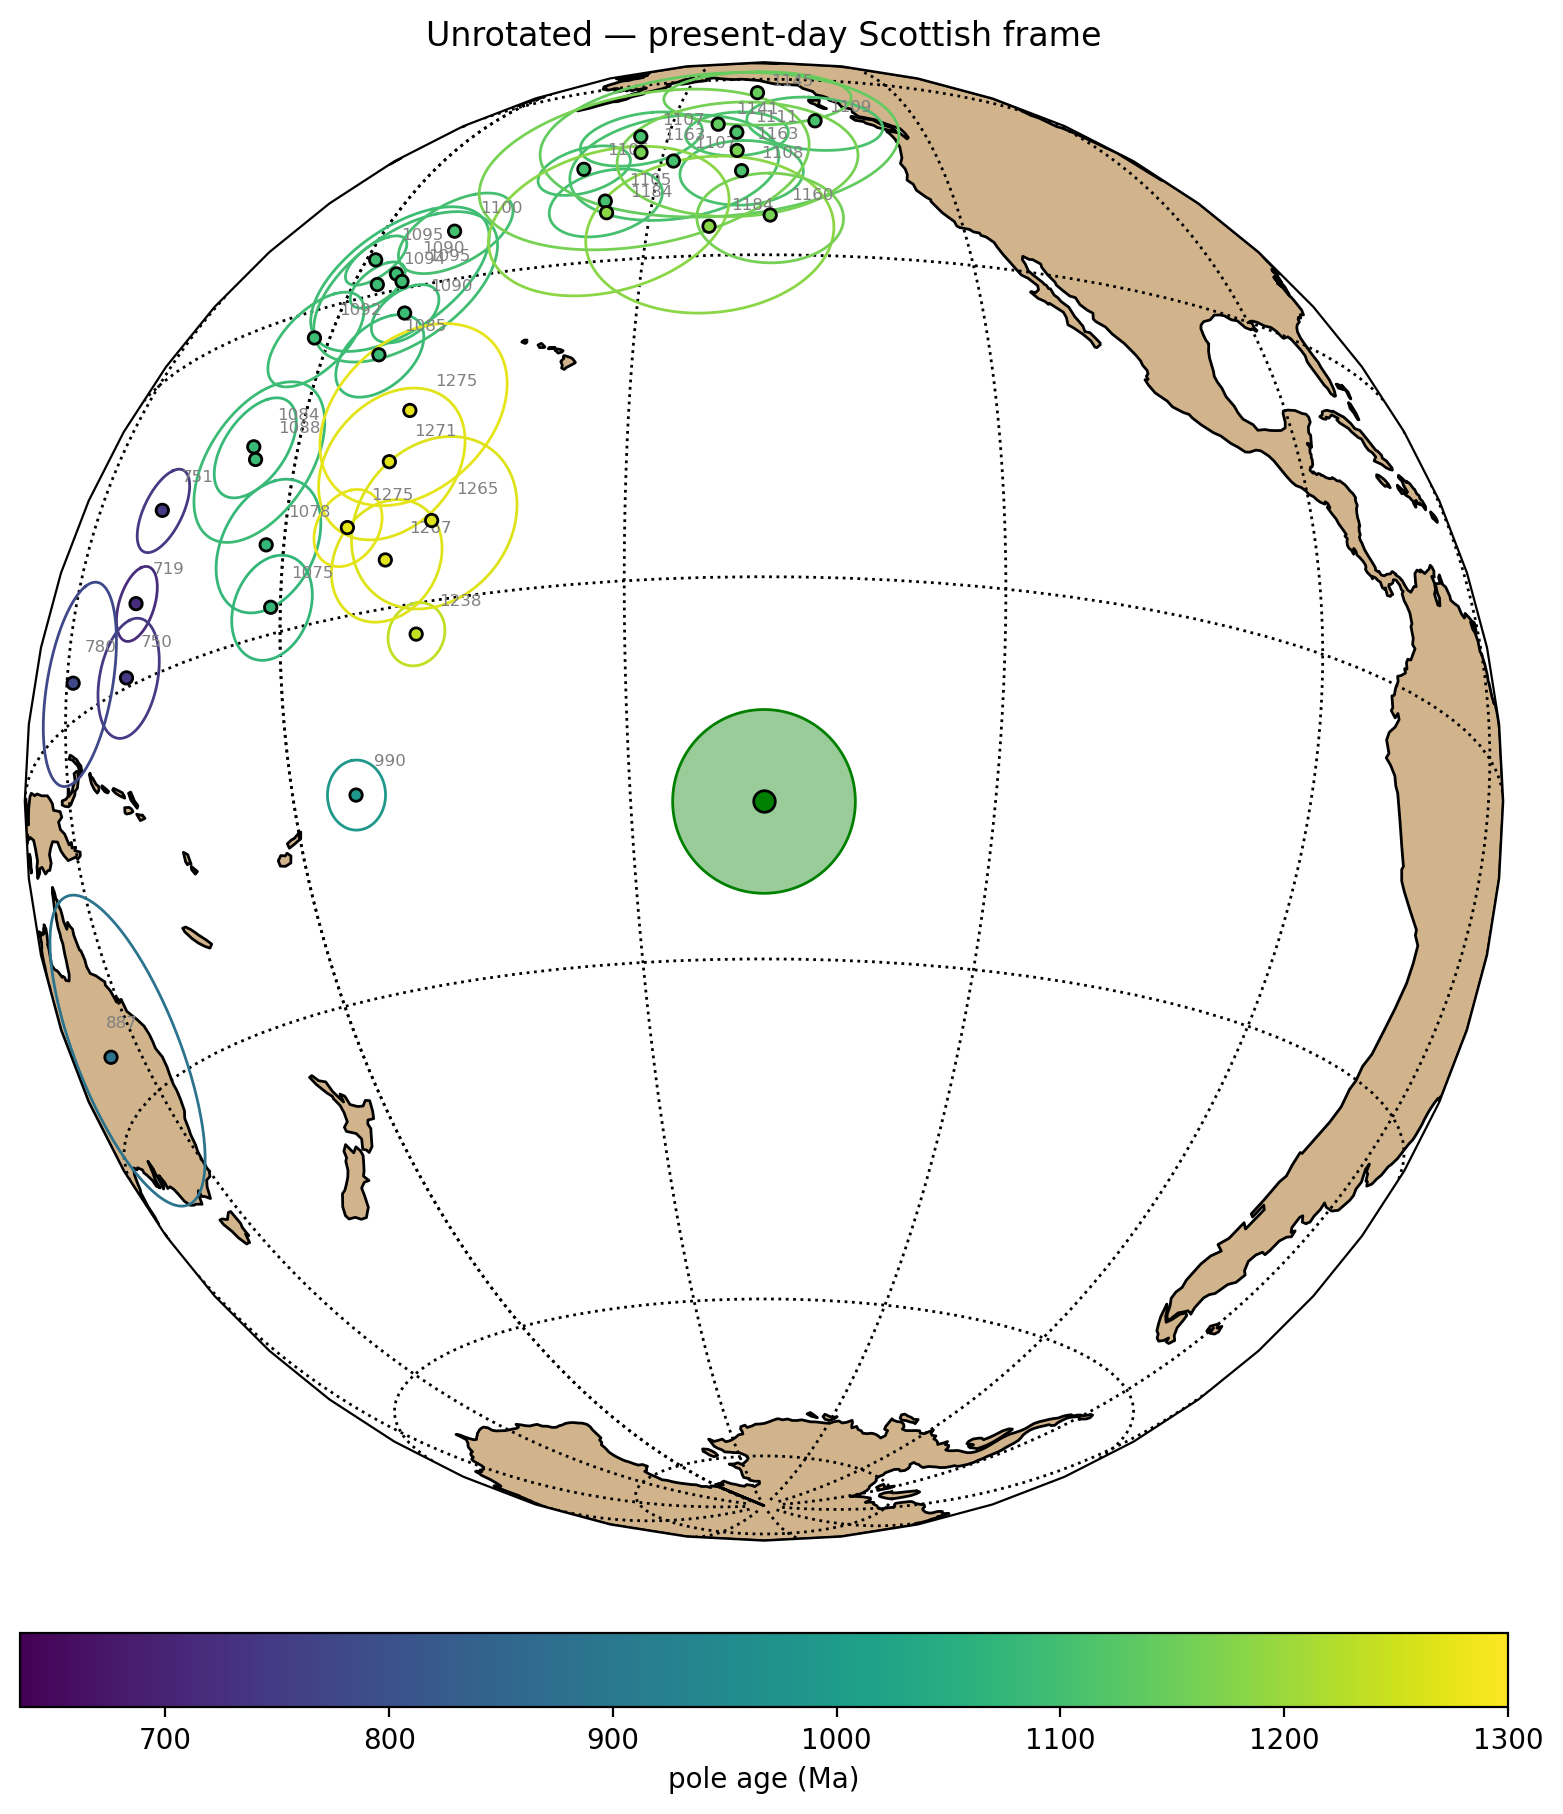

In [5]:
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1300,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.title('Unrotated — present-day Scottish frame')
plt.show()

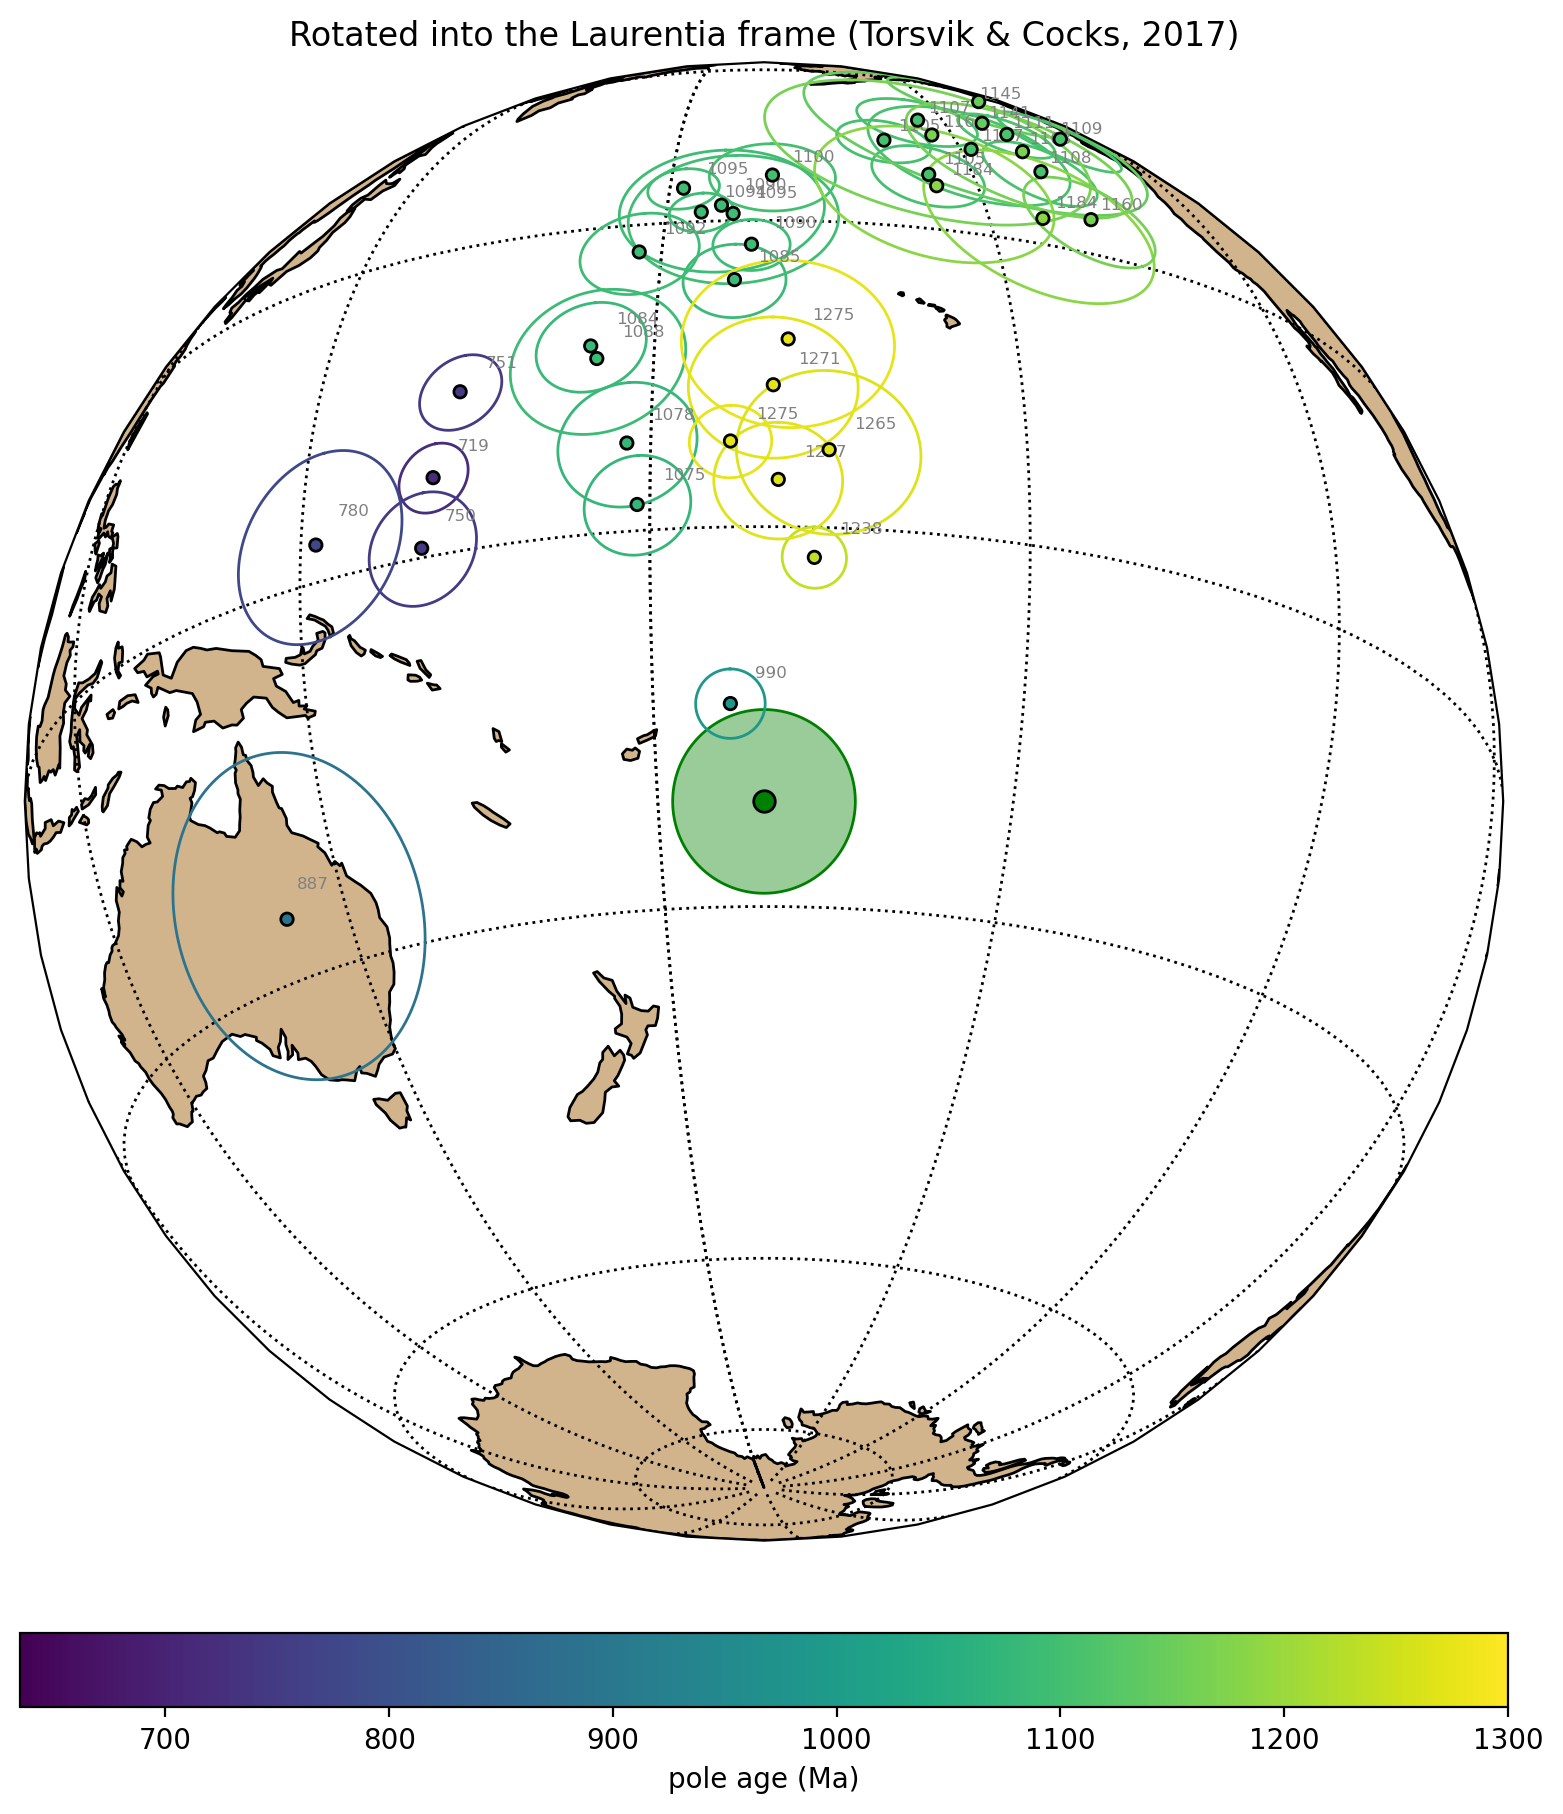

In [6]:
ax = pt.plot_apwp_context(Laurentia_poles, pole_rotated['inc'], pole_rotated['dec'],
                          pole_rotated['alpha95'], age_min=635, age_max=1300,
                          projection='orthographic',
                          central_longitude=pole_rotated['dec'],
                          central_latitude=pole_rotated['inc'])
plt.title('Rotated into the Laurentia frame (Torsvik & Cocks, 2017)')
plt.show()

## Comparison with younger Laurentia poles

The same `plot_pole_overlap` comparison is shown for both positions.

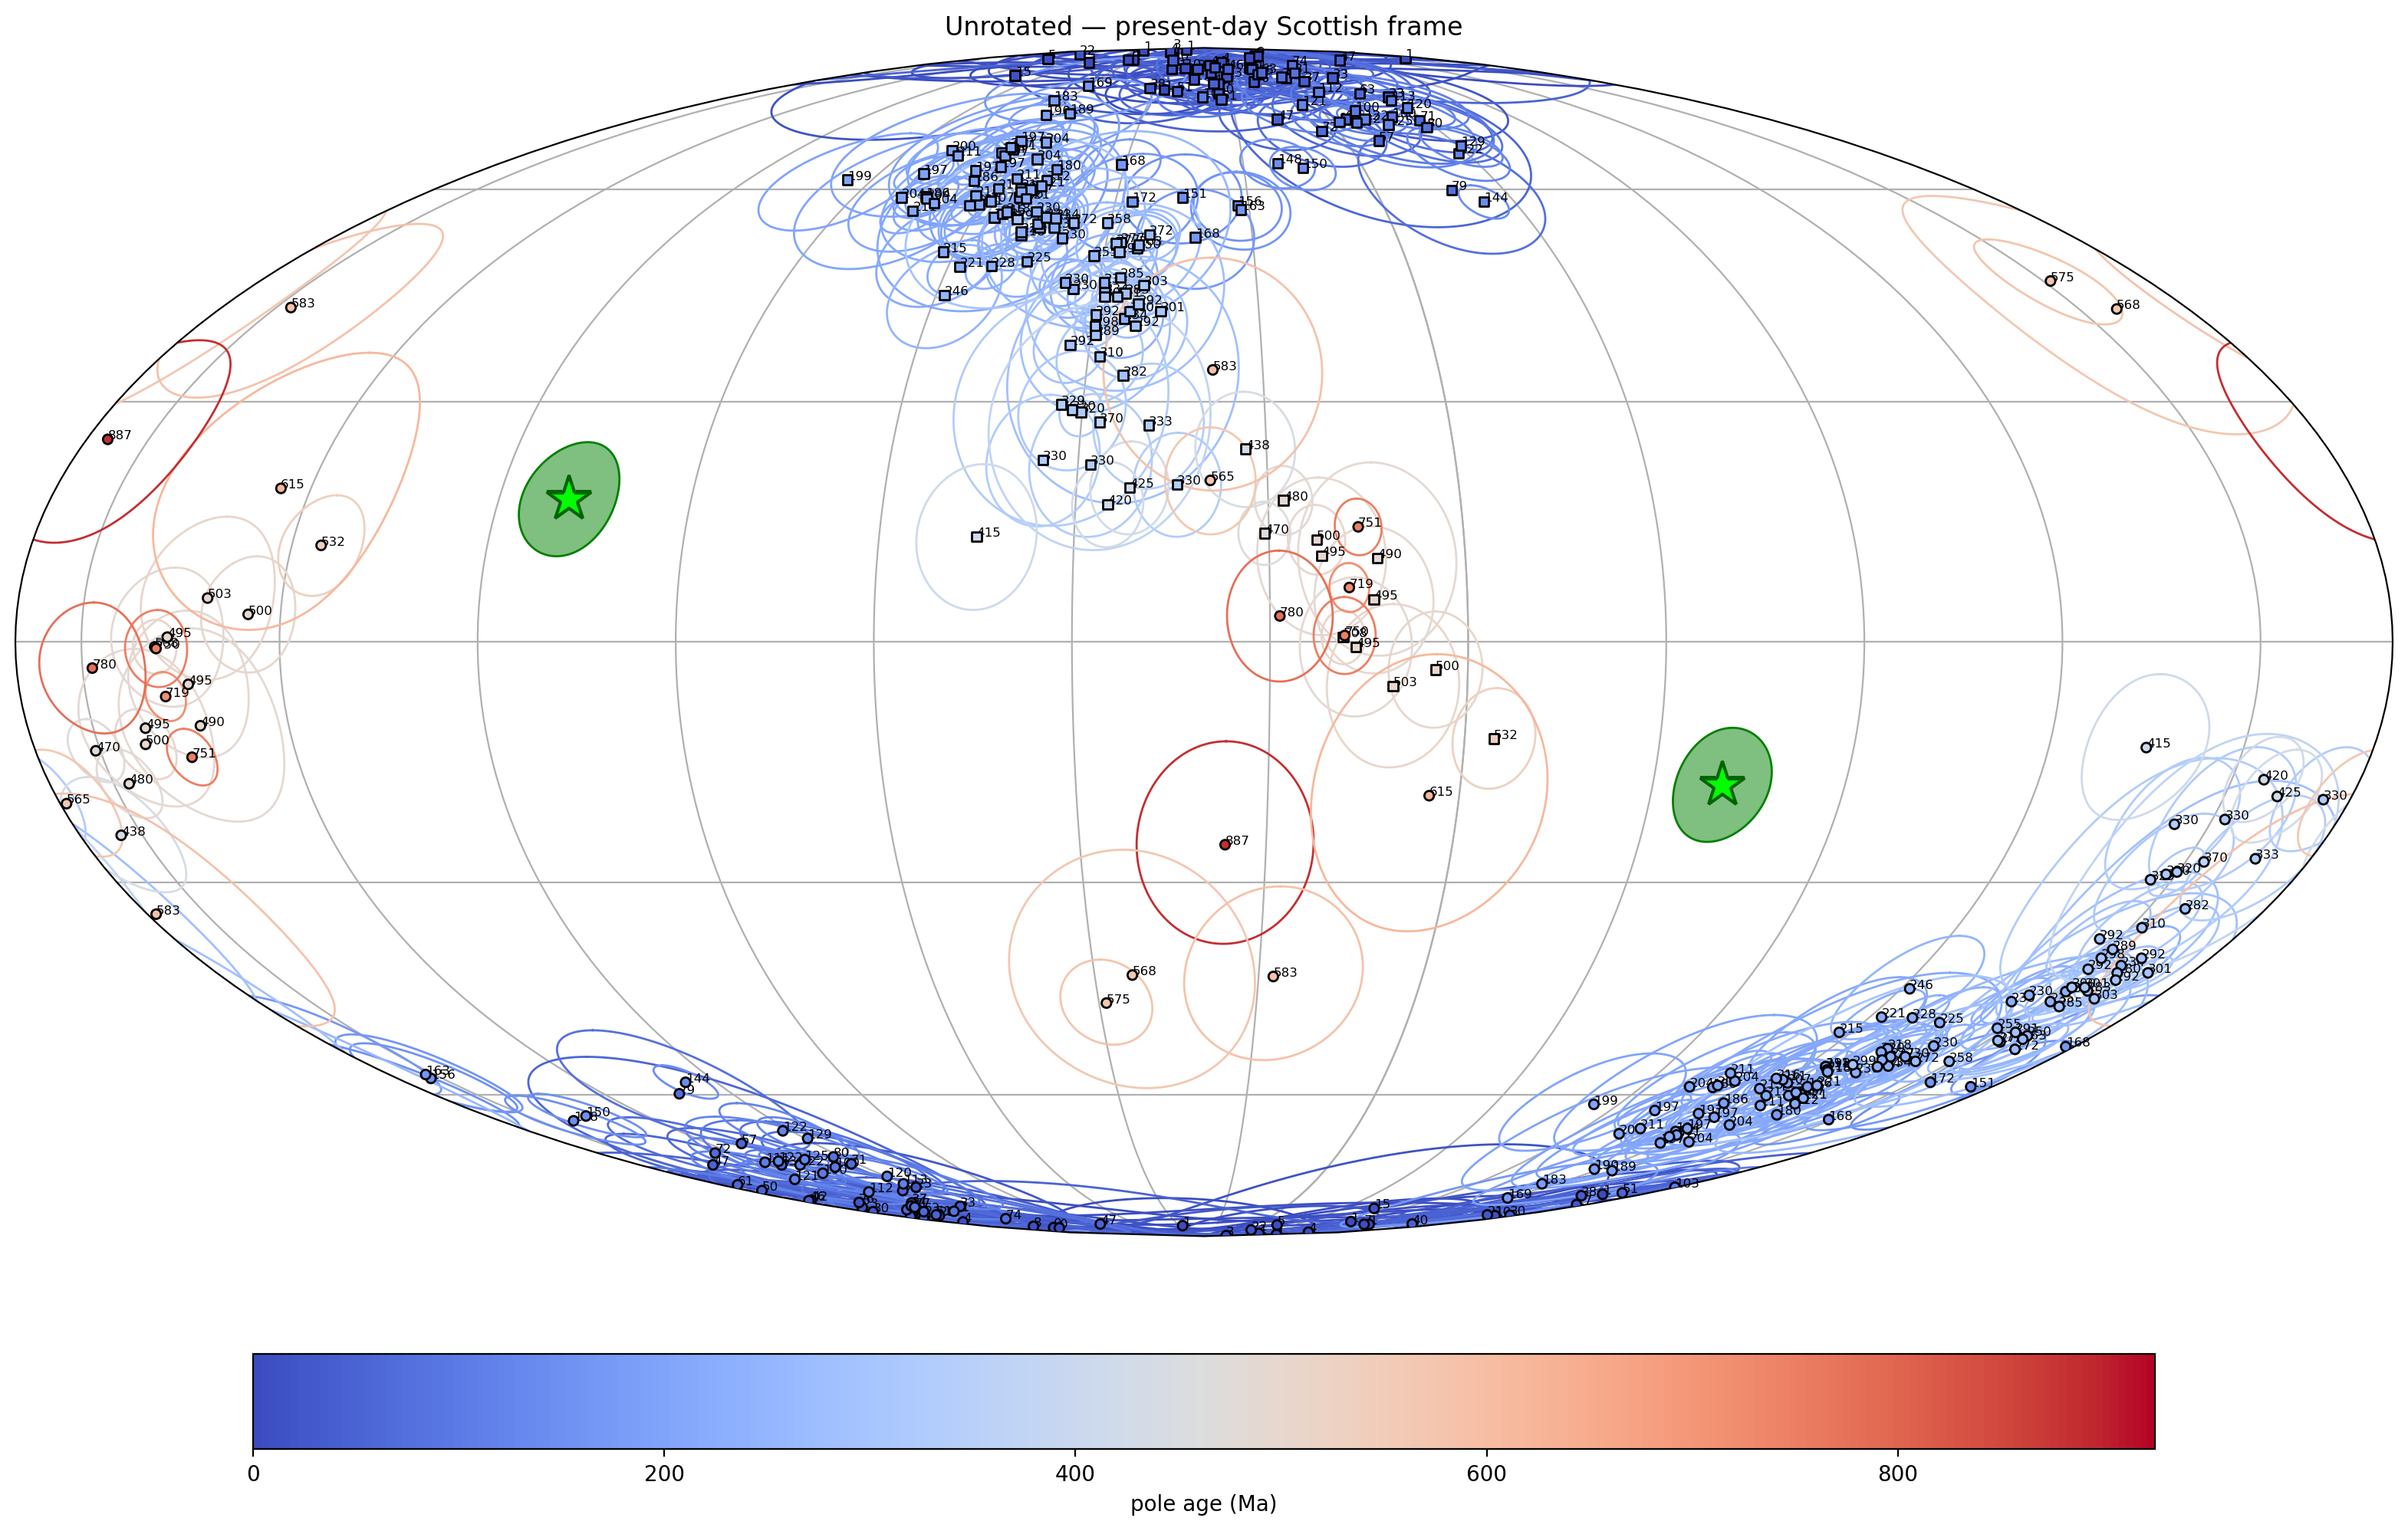

In [7]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('MEAN Torridon Group', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=925, show=False)
plt.title('Unrotated — present-day Scottish frame')
plt.show()

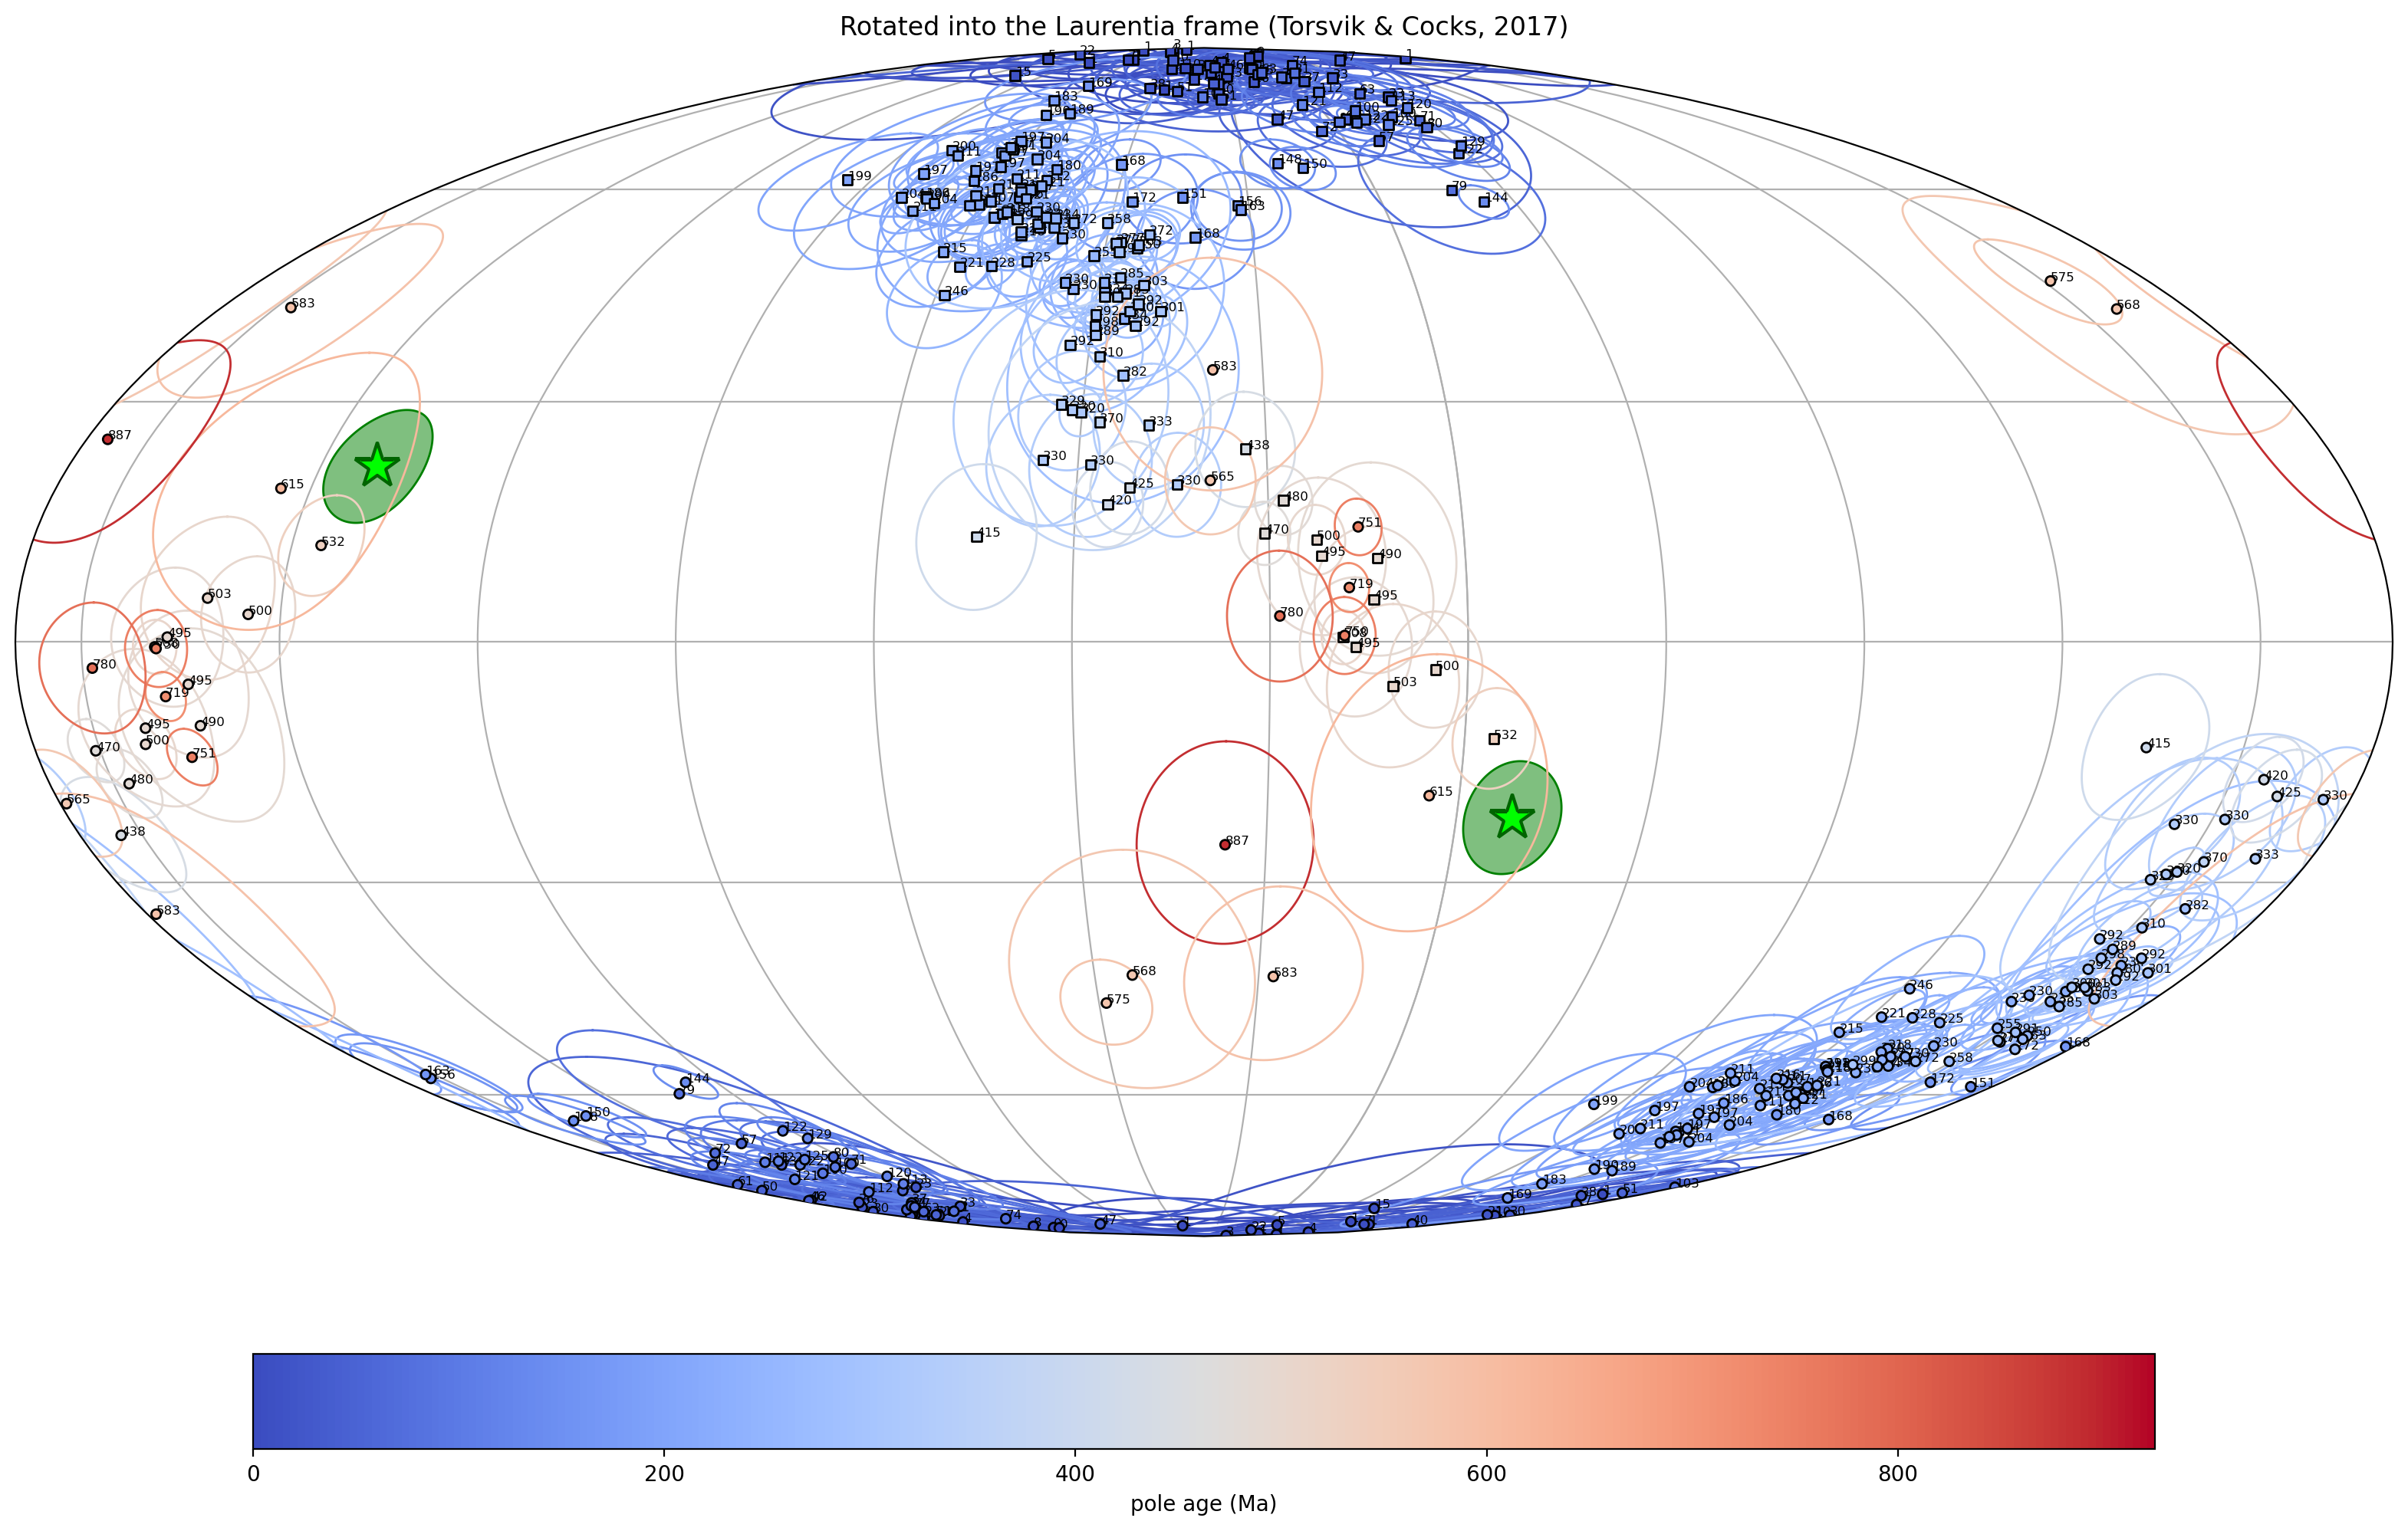

In [8]:
pt.plot_pole_overlap('MEAN Torridon Group', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_rotated['inc'], pole_plon=pole_rotated['dec'],
                     pole_A95=pole_rotated['alpha95'], pole_age=925, show=False)
plt.title('Rotated into the Laurentia frame (Torsvik & Cocks, 2017)')
plt.show()

## Nordic workshop summary

The pole is exported in the Nordic compilation format **without Euler rotation** (published Scottish coordinates). Because this is a published grand mean of unit means rather than a recomputed site-level pole, the site count (B) is left blank and the direction precision (KD = 1000, ED95 = 0.1) are the placeholder/sentinel values carried in the source compilation; the meaningful quantities are the pole position and A95.

In [9]:
# grand mean of unit means: one placeholder 'sites' row carrying the sample count + tilt state
row_sites = pd.DataFrame([{'dir_tilt_correction': int(float(row['TILT'])),
                           'dir_n_samples': int(float(row['N']))}])

summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Torridon Group',
    sites=row_sites,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=float(row['SLONG']),
    study_lat=float(row['SLAT']),
    component_comment='Sample-weighted grand mean of seven Torridon Group studies (Irving & Runcorn 1957; Stewart & Irving 1974; Smith et al. 1983; Torsvik & Sturt 1987; Potts 1990; Williams & Schmidt 1997; Borradaile & Geneviciene 2008); mixed polarity',
    tests='f (fold/field tests across the constituent studies; "many" per Evans et al., 2021)',
    gpmdb_number='',
    magic_id='',
    percent_reversed='',          # source lists '%REV = MIXED' (dual polarity); see comment
    demag_code=int(float(row['DEMAGCODE'])),
    R1=0, R2=1, R3=1, R4='f',
    R5=0, R6=0, R7=1, Grade='B',
    nominal_age=925,
    lomagage=780, himagage=1070,
    REF_method="The Torridon Group is poorly dated directly. Its youngest detrital zircon populations indicate deposition younger than ca. 1050 Ma (as summarized by Krabbendam et al., 2022), while the absence of Cryogenian glacial deposits indicates it is older than ca. 720 Ma. The pole is assigned **ca. 925 Ma (780-1070 Ma)**; in terms of apparent-polar-wander comparison it is quite similar to the ca. 990 Ma Jacobsville pole.",
    POLE_AUTHORS='Lulea Working Group mean (Evans et al., 2021 compilation)',
    YEAR=2009,
    JOURNAL='',
    VOLUME='',
    VPAGES='',
    TITLE='MEAN Torridon Group (Lulea Working Group grand mean)',
    COMMENT='Pole taken from the Evans et al. (2021) Laurentia compilation (Lulea Working Group seven-study sample-weighted grand mean, 2009), reported in unrotated (present-day Scottish) coordinates - Euler rotation into the Laurentia frame is deferred to later workflows. Mixed polarity (%REV = MIXED in the source). The KD = 1000 / ED95 = 0.1 fields and blank B are sentinel/placeholder values of the source mean-of-means. Age assigned ca. 925 Ma (detrital-zircon maximum age <1050 Ma; older than ca. 720 Ma; Krabbendam et al., 2022).'
)
pt.save_nordic_summary(summary, '925_Torridon')
summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,Torridon Group,,Sample-weighted grand mean of seven Torridon G...,f (fold/field tests across the constituent stu...,100,57.9,354.3,,880,...,1070,Youngest detrital zircons indicate deposition ...,Torridon Group,"Lulea Working Group mean (Evans et al., 2021 c...",2009,,,,MEAN Torridon Group (Lulea Working Group grand...,Pole taken from the Evans et al. (2021) Lauren...
